# Section 1 - Imports & Setup


### 1.1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random
import joblib
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


### 1.2 - Path Setup and Data Loading

In [3]:
import sys
from pathlib import Path

# Define the Root (at SCANIA COMPONENT X)
PROJECT_ROOT = Path.cwd().parent

# Data Directory (Matches your "Data/Processed Data" folder exactly)
DATA_DIR = PROJECT_ROOT / "Data" / "Processed Data"

# Results Hierarchy
RESULTS_DIR = PROJECT_ROOT / "Results"
MODEL_DIR = RESULTS_DIR / "Models"
PREDICTION_DIR = RESULTS_DIR / "Predictions"

# Adding root to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Diagnostic Prints
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")
print(f"Model Path:   {MODEL_DIR}")
print(f"Predictions:  {PREDICTION_DIR}")

# Test if we can see the data file aka. if the path set-up is correct and the file exists
test_file = DATA_DIR / "val_processed.csv"
if test_file.exists():
    print(f"Success! Found {test_file}")
else:
    raise FileNotFoundError(f"Missing expected file: {test_file}")

Project Root: c:\Users\Elias\Documents\SCANIA Component X
Data Source:  c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data
Model Path:   c:\Users\Elias\Documents\SCANIA Component X\Results\Models
Predictions:  c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions
Success! Found c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data\val_processed.csv


In [4]:
import importlib
import utils

importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Elias\\Documents\\SCANIA Component X\\utils\\__init__.py'>

### 1.3: Data Loading and Verification

In [5]:
# Importing the data files into pandas DataFrames. Skipping test_processed, as it will be used in the next notebook and not here.
train_data = pd.read_csv(DATA_DIR / 'train_processed.csv')
val_data   = pd.read_csv(DATA_DIR / 'val_processed.csv')

print("=== LOADED SUCCESSFULLY ===")
print(f"Training Data:   {train_data.shape}")
print(f"Validation Data: {val_data.shape}")


=== LOADED SUCCESSFULLY ===
Training Data:   (1122452, 108)
Validation Data: (196227, 108)


In [7]:
# Double checking the sizes of the loaded data and labels
print("=== Dataset Shapes ===")
print(f"Training Data: {train_data.shape}")
print(f"Validation Data: {val_data.shape}")
print('\n')

# Double cheking that no NaN values have snuck in
print("=== Checking for Missing values  ===")
print(f"Training Data: {train_data.isnull().sum().sum()}")
print(f"Validation Data: {val_data.isnull().sum().sum()}")
print('\n')

print("=== Label Distributions ===")
print(f"Train labels:\n{train_data['label'].value_counts()}")
print(f"Validation labels:\n{val_data['label'].value_counts()}")

train_data.head()


=== Dataset Shapes ===
Training Data: (1122452, 108)
Validation Data: (196227, 108)


=== Checking for Missing values  ===
Training Data: 0
Validation Data: 0


=== Label Distributions ===
Train labels:
label
0    1060229
1      62223
Name: count, dtype: int64
Validation labels:
label
0    192709
1      3518
Name: count, dtype: int64


,vehicle_id,time_step,label,171_0_delta,666_0_delta,427_0_delta,837_0_delta,167_0_delta,167_1_delta,167_2_delta,...,397_26_delta,397_27_delta,397_28_delta,397_29_delta,397_30_delta,397_31_delta,397_32_delta,397_33_delta,397_34_delta,397_35_delta
0,0,11.2,0,-0.637465,-0.476575,-0.686321,-0.222826,0.0,-0.549047,-0.614345,...,-0.539610,-0.556290,-0.426540,-0.1,-0.531250,-0.464286,-0.478710,-0.441154,-0.321354,-0.166667
1,0,11.4,0,-0.637465,-0.476575,-0.686321,-0.222826,1.0,-0.522925,-0.614345,...,-0.539592,-0.556070,-0.426540,-0.1,-0.531250,-0.464286,-0.478692,-0.441154,-0.321354,-0.166667
2,0,19.6,0,0.621768,0.386107,0.635999,-0.016304,0.0,-0.549047,-0.614345,...,0.294371,0.248513,0.114929,0.3,0.637868,2.023141,0.453481,0.352541,0.054302,-0.166667
3,0,20.2,0,-0.457872,-0.363489,-0.505609,-0.211957,0.0,-0.549047,-0.614345,...,-0.404093,-0.430932,-0.330569,-0.1,-0.487132,-0.151968,-0.380828,-0.364662,-0.295121,-0.125000
4,0,21.0,0,-0.556094,-0.411955,-0.596363,-0.152174,0.0,-0.549047,-0.614345,...,-0.445057,-0.393038,-0.379147,-0.1,-0.529412,-0.360969,-0.386612,-0.335523,-0.287513,-0.125000


# Section 2 - Data Input Preparation



### 2.1 - Inspecting the Data on how to arrange the sequence inputs based on its shape

In [8]:
# Checking the statistics of the overall training data
seq_lengths = train_data.groupby('vehicle_id')['time_step'].count()
seq_lengths.describe()

count    23550.000000
mean        47.662505
std         27.406028
min          5.000000
25%         28.000000
50%         43.000000
75%         64.000000
max        303.000000
Name: time_step, dtype: float64

In [9]:
# Checking the statistics of the failed classes from the training data
failed_vehicles = train_data[train_data['label'] == 1]['vehicle_id'].unique()
seq_lengths[failed_vehicles].describe()

count    2272.000000
mean       46.589789
std        24.156813
min         5.000000
25%        29.000000
50%        43.000000
75%        60.000000
max       236.000000
Name: time_step, dtype: float64

The distribution of the failed classes and the overall data seems to follow the same distribution, which could also bee seen in the Data preparation Notebook dring the EDA. For us, this means that we can pick a sequence size that follows this distribution. Since the most recent readings are most informative for failure prediction, sequences longer than the N timesteps chosen will be truncated and keeping the m last entries. Sequences that are shorter will be padded with zeros at the begining of their sequence. The chosen length is initialized below.

In [10]:
SEQ_LEN = 30

### 2.2 - Generating the Input Data

In [11]:
# For the LR data
X_train_lr, y_train_lr = utils.prepare_lr_data(train_data, 'label')
X_val_lr, y_val_lr = utils.prepare_lr_data(val_data, 'label')

# For the sequential data
X_train_seq, y_train_seq = utils.generate_sequential_data(train_data, 'label', SEQ_LEN)
X_val_seq, y_val_seq = utils.generate_sequential_data(val_data, 'label', SEQ_LEN)

INPUT_SIZE = X_train_seq.shape[2]


In [12]:
# Printing Statistical information on the Sequential Data
print("=== Statistical Properites ===")
print("=== Seqential Data == ")
print(f"Train mean: {X_train_seq.mean():.3f}, std: {X_train_seq.std():.3f}")
print(f"Val mean:   {X_val_seq.mean():.3f}, std: {X_val_seq.std():.3f}")



=== Statistical Properites ===
=== Seqential Data == 
Train mean: 40.788, std: 1221.997
Val mean:   34.576, std: 1085.395


# Section 3 - Model Training

## 3.1 - Logistic Regression

### 3.1.1 - Logistic Regression Functions

In [13]:
from sklearn.linear_model import LogisticRegression

def train_lr_model(X, y):
  lr_model = LogisticRegression(class_weight='balanced', random_state=SEED, max_iter=1000, C=0.1, l1_ratio=1, solver='liblinear')
  lr_model.fit(X, y)

  return lr_model

def get_lr_predictions(model, X):
  predictions = model.predict(X)
  probabilities = model.predict_proba(X)[:,1]

  return predictions, probabilities

def save_lr_predictions(X, predictions, probabilities, path):
  vehicle = X.index.values

  predictions_df = pd.DataFrame({
      'vehicle_id': vehicle,
      'probability': probabilities,
      'binary_prediction': predictions
  })

  print("Saving the DataFrame...")
  predictions_df.to_csv(path, index=False)
  print(f"DataFrame saved to {path}")

  return None

def save_lr_model(model, path):
  print("Saving the model...")
  joblib.dump(model, path)
  print(f"Model saved to {path}")

  return None

### 3.1.2 -  Training & Evaluation

___________________________________________
Standard Metrics:
{'Recall': 0.8676470588235294, 'Precision': 0.03525545264415895, 'F1': 0.06775768016078093, 'AUC-ROC': 0.6619429136216605, 'AUC-PR': 0.04935477051288454}

Prediction distribution:
1    3347
0    1699
Name: count, dtype: int64


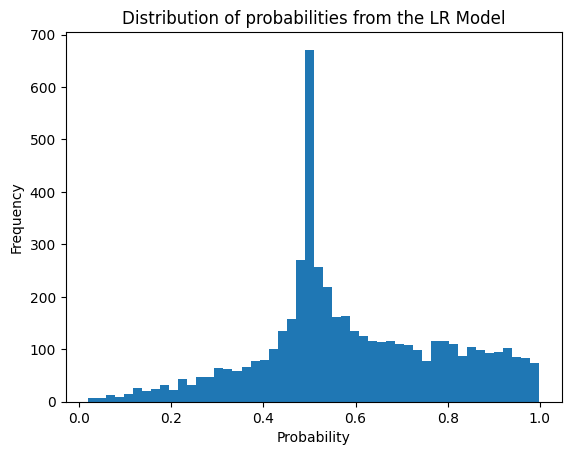

In [14]:
# Train
lr_model = train_lr_model(X_train_lr, y_train_lr)

# Predict
pred, prob = get_lr_predictions(lr_model, X_val_lr)

# Evaluate — use the same metrics as BaseTrainer for consistency
lr_metrics = {
    'Recall': recall_score(y_val_lr, pred),
    'Precision': precision_score(y_val_lr, pred),
    'F1': f1_score(y_val_lr, pred),
    'AUC-ROC': roc_auc_score(y_val_lr, prob),
    'AUC-PR': average_precision_score(y_val_lr, prob),
}

print("___________________________________________")
print("Standard Metrics:")
print(lr_metrics)

# Prediction distribution
print(f"\nPrediction distribution:\n{pd.Series(pred).value_counts()}")

# Histogram
plt.hist(prob, bins=50)
plt.title('Distribution of probabilities from the LR Model')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()

#### **Summary**
The LR Model was trained on the last timestep of each of the vehicle's readouts usint `class_weight = 'balanced'` to account for the severe class imbalance in the data set. The ratio between recall and precision as well as AUC ROC vs PR tells us that the model was able to gain some separability on the classes, but is far from stron. The distribution is concentrated around 0.5 which tells us it is a little better than randomly assigning the labels.

Furthermore, the aggressive class weighting also caused the model to flag nearly half of all vehicles as potential failures. It would probably be worse off overall if we did not include it, since false negatives are our biggest concern, however it indicates that the model is far from usable in rea industrial maintanance settings.

In conclusion, we have experienced expected behaviour from this model. THe Logisitic Regression is used only as a baseline model that is trained on the heavily imbalanced data set. The main goal here is to serve as a reference against LSTM / TCN but as well as data augmentation methods.

## 3.2 -  LSTM

### 3.2.1 -  Hyperparameters

In [15]:
HIDDEN_SIZE = 64
NUM_LAYERS = 1
LEARNING_RATE = 0.0005
BATCH_SIZE = 32
NUM_EPOCHS = 1000
PATIENCE = 15
DROPOUT = 0.4
CLIP_GRAD = 1.0

### 3.2.3 - Model Training

In [16]:
# Creating the Model
lstm = utils.LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

# Creating the Trainer
lstm_trainer = utils.BaseTrainer(
    model=lstm,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    clip_grad=CLIP_GRAD
)

In [17]:
# Fitting on the training data and validating on the validation data, with early stopping and model checkpointing.
lstm_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'lstm_model_best.pt'
);

Epoch 1/1000 Complete - Time: 2.85 seconds
Epoch 1/1000 - Train: 1.2368 - Val: 0.7813
___________________________________
Epoch 2/1000 Complete - Time: 2.74 seconds
Epoch 2/1000 - Train: 1.1842 - Val: 0.8212
___________________________________
Epoch 3/1000 Complete - Time: 2.69 seconds
Epoch 3/1000 - Train: 1.1566 - Val: 0.7713
___________________________________
Epoch 4/1000 Complete - Time: 2.74 seconds
Epoch 4/1000 - Train: 1.1369 - Val: 0.7390
___________________________________
Epoch 5/1000 Complete - Time: 2.73 seconds
Epoch 5/1000 - Train: 1.1203 - Val: 0.7826
___________________________________
Epoch 6/1000 Complete - Time: 2.75 seconds
Epoch 6/1000 - Train: 1.1058 - Val: 0.8863
___________________________________
Epoch 7/1000 Complete - Time: 2.74 seconds
Epoch 7/1000 - Train: 1.0845 - Val: 0.7751
___________________________________
Epoch 8/1000 Complete - Time: 2.82 seconds
Epoch 8/1000 - Train: 1.0806 - Val: 0.7604
___________________________________
Epoch 9/1000 Complete - 

### 3.2.4 -  Evaluation

___________________________________________
Standard Metrics:
Recall      : 0.6103
Precision   : 0.0528
F1          : 0.0972
AUC-ROC     : 0.6877
AUC-PR      : 0.0618


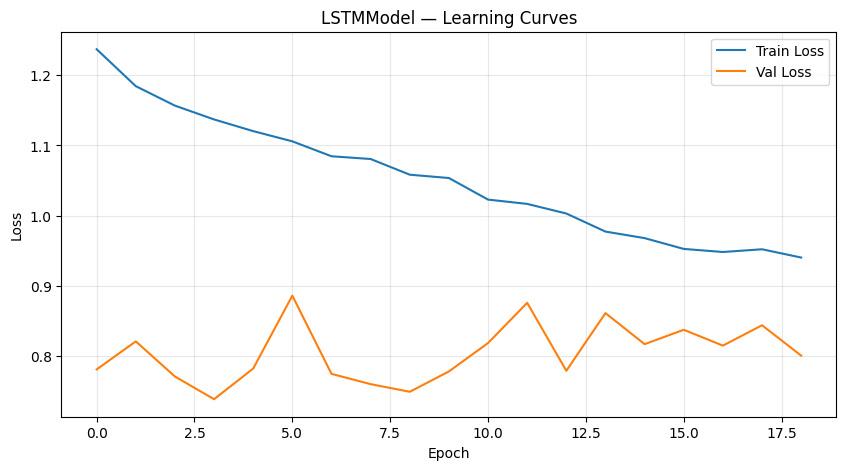

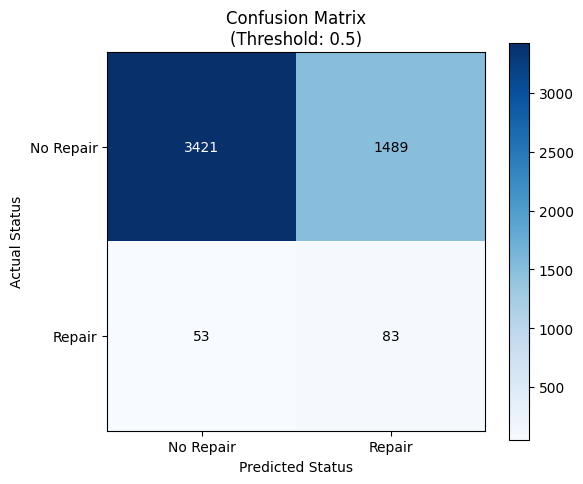

In [18]:
lstm_trainer.evaluate(X_val_seq, y_val_seq)
lstm_trainer.plot_history()
lstm_trainer.plot_cm(X_val_seq, y_val_seq)

## 3.3 - TCN

### 3.3.1 -  Hyperparameters

In [40]:
TCN_NUM_CHANNELS = 64
TCN_KERNEL_SIZE = 3
TCN_NUM_LAYERS = 3
TCN_LEARNING_RATE = 0.00001
TCN_BATCH_SIZE = 32
TCN_NUM_EPOCHS = 1000
TCN_DROPOUT = 0.3

### 3.3.2 -  Model Training

In [42]:
# Creating the TCN model
tcn = utils.TCNModel(
    input_size=INPUT_SIZE,
    num_channels=TCN_NUM_CHANNELS,
    num_layers=TCN_NUM_LAYERS,
    kernel_size=TCN_KERNEL_SIZE,
    dropout=TCN_DROPOUT
)

# Creating the TCN trainer
tcn_trainer = utils.BaseTrainer(
    model=tcn,
    lr=TCN_LEARNING_RATE,
    batch_size=TCN_BATCH_SIZE,
    clip_grad=None
)



In [43]:
# Fitting on the training data and validating on the validation data, with early stopping and model checkpointing.
tcn_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=TCN_NUM_EPOCHS,
    patience=15,
    save_path=MODEL_DIR / 'tcn_model_best.pt'
);

Epoch 1/1000 Complete - Time: 5.45 seconds
Epoch 1/1000 - Train: 34.1659 - Val: 8.5982
___________________________________
Epoch 2/1000 Complete - Time: 5.42 seconds
Epoch 2/1000 - Train: 10.2771 - Val: 1.5426
___________________________________
Epoch 3/1000 Complete - Time: 5.45 seconds
Epoch 3/1000 - Train: 2.0860 - Val: 1.8175
___________________________________
Epoch 4/1000 Complete - Time: 5.47 seconds
Epoch 4/1000 - Train: 1.8492 - Val: 0.9574
___________________________________
Epoch 5/1000 Complete - Time: 5.62 seconds
Epoch 5/1000 - Train: 1.6609 - Val: 0.9911
___________________________________
Epoch 6/1000 Complete - Time: 5.56 seconds
Epoch 6/1000 - Train: 1.5867 - Val: 0.8993
___________________________________
Epoch 7/1000 Complete - Time: 6.01 seconds
Epoch 7/1000 - Train: 1.4877 - Val: 0.9695
___________________________________
Epoch 8/1000 Complete - Time: 6.29 seconds
Epoch 8/1000 - Train: 1.4415 - Val: 1.2421
___________________________________
Epoch 9/1000 Complete 

### 3.3.3 -  Evaluation

___________________________________________
Standard Metrics:
Recall      : 0.5441
Precision   : 0.0347
F1          : 0.0652
AUC-ROC     : 0.6146
AUC-PR      : 0.0636


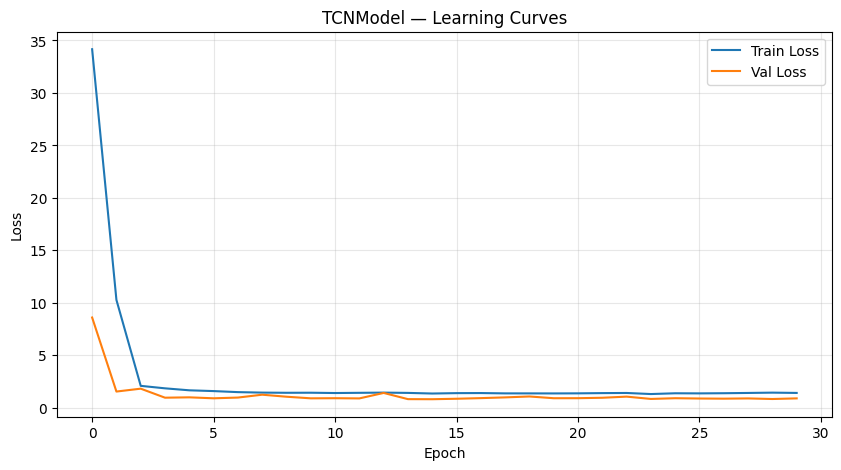

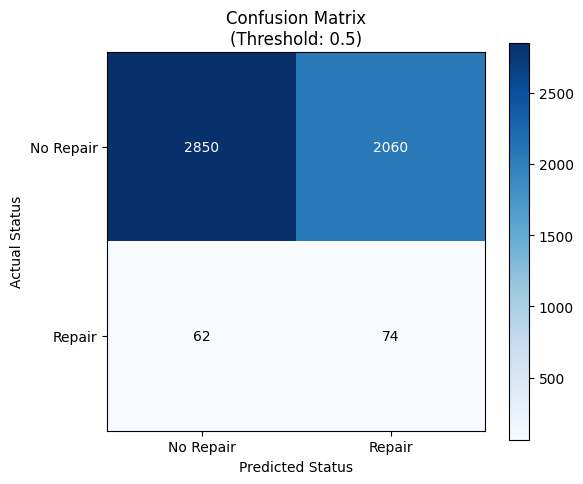

In [44]:
# Evaluating the TCN model on the validation set and plotting the results
tcn_trainer.evaluate(X_val_seq, y_val_seq)
tcn_trainer.plot_history()
tcn_trainer.plot_cm(X_val_seq, y_val_seq)

## 3.4  - Model Comparison

### 3.4. -  Comparison at Baseline Threshold

In [45]:
lstm_metrics, lstm_preds, lstm_probs = lstm_trainer.evaluate(X_val_seq, y_val_seq)
tcn_metrics, tcn_preds, tcn_probs = tcn_trainer.evaluate(X_val_seq, y_val_seq)

comparison = pd.DataFrame({
    'LR': lr_metrics,
    'LSTM': lstm_metrics,
    'TCN': tcn_metrics,
})
print(comparison.round(4))

___________________________________________
Standard Metrics:
Recall      : 0.6103
Precision   : 0.0528
F1          : 0.0972
AUC-ROC     : 0.6877
AUC-PR      : 0.0618
___________________________________________
Standard Metrics:
Recall      : 0.5441
Precision   : 0.0347
F1          : 0.0652
AUC-ROC     : 0.6146
AUC-PR      : 0.0636
               LR    LSTM     TCN
Recall     0.8676  0.6103  0.5441
Precision  0.0353  0.0528  0.0347
F1         0.0678  0.0972  0.0652
AUC-ROC    0.6619  0.6877  0.6146
AUC-PR     0.0494  0.0618  0.0636


##### 3.4.2 -  LSTM

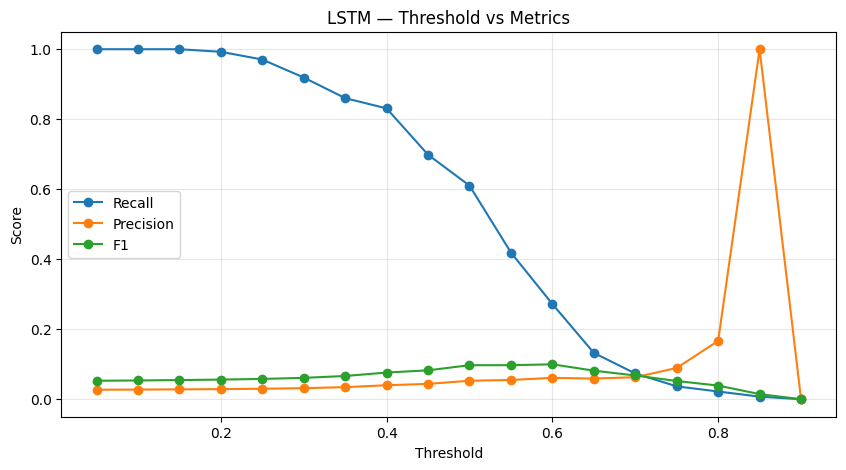

 Threshold  Recall  Precision     F1
      0.05  1.0000     0.0271 0.0528
      0.10  1.0000     0.0275 0.0536
      0.15  1.0000     0.0282 0.0548
      0.20  0.9926     0.0288 0.0560
      0.25  0.9706     0.0299 0.0580
      0.30  0.9191     0.0316 0.0610
      0.35  0.8603     0.0345 0.0664
      0.40  0.8309     0.0399 0.0762
      0.45  0.6985     0.0439 0.0825
      0.50  0.6103     0.0528 0.0972
      0.55  0.4191     0.0550 0.0972
      0.60  0.2721     0.0611 0.0997
      0.65  0.1324     0.0590 0.0816
      0.70  0.0735     0.0629 0.0678
      0.75  0.0368     0.0893 0.0521
      0.80  0.0221     0.1667 0.0390
      0.85  0.0074     1.0000 0.0146
      0.90  0.0000     0.0000 0.0000


In [46]:
thresholds = np.arange(0.05, 0.95, 0.05)
lstm_results = []

for t in thresholds:
    preds = (lstm_probs > t).astype(int)
    lstm_results.append({
        'Threshold': t,
        'Recall': recall_score(y_val_seq, preds),
        'Precision': precision_score(y_val_seq, preds, zero_division=0),
        'F1': f1_score(y_val_seq, preds),
    })

results_df = pd.DataFrame(lstm_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['Threshold'], results_df['Recall'], label='Recall', marker='o')
ax.plot(results_df['Threshold'], results_df['Precision'], label='Precision', marker='o')
ax.plot(results_df['Threshold'], results_df['F1'], label='F1', marker='o')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('LSTM — Threshold vs Metrics')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(results_df.round(4).to_string(index=False))

#### 3.4.3 - TCN

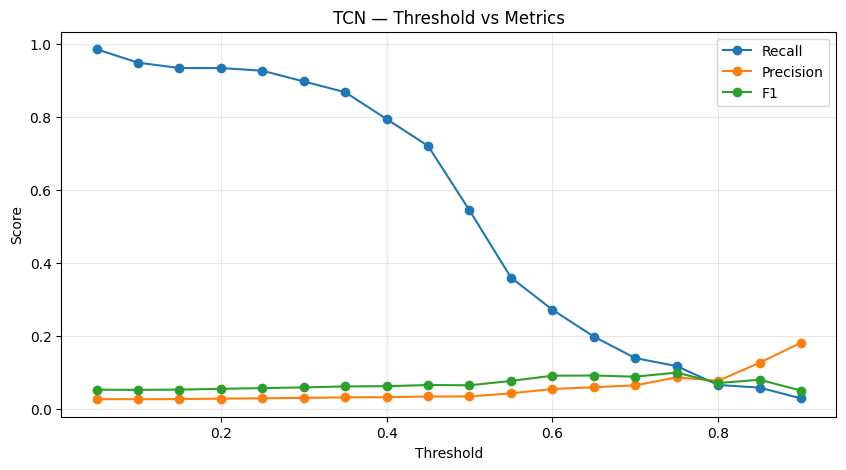

 Threshold  Recall  Precision     F1
      0.05  0.9853     0.0273 0.0532
      0.10  0.9485     0.0271 0.0527
      0.15  0.9338     0.0275 0.0534
      0.20  0.9338     0.0286 0.0555
      0.25  0.9265     0.0297 0.0575
      0.30  0.8971     0.0307 0.0594
      0.35  0.8676     0.0322 0.0622
      0.40  0.7941     0.0327 0.0628
      0.45  0.7206     0.0345 0.0659
      0.50  0.5441     0.0347 0.0652
      0.55  0.3603     0.0432 0.0771
      0.60  0.2721     0.0550 0.0915
      0.65  0.1985     0.0599 0.0920
      0.70  0.1397     0.0651 0.0888
      0.75  0.1176     0.0870 0.1000
      0.80  0.0662     0.0776 0.0714
      0.85  0.0588     0.1270 0.0804
      0.90  0.0294     0.1818 0.0506


In [47]:
thresholds = np.arange(0.05, 0.95, 0.05)
tcn_results = []

for t in thresholds:
    preds = (tcn_probs > t).astype(int)
    tcn_results.append({
        'Threshold': t,
        'Recall': recall_score(y_val_seq, preds),
        'Precision': precision_score(y_val_seq, preds, zero_division=0),
        'F1': f1_score(y_val_seq, preds),
    })

results_df = pd.DataFrame(tcn_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['Threshold'], results_df['Recall'], label='Recall', marker='o')
ax.plot(results_df['Threshold'], results_df['Precision'], label='Precision', marker='o')
ax.plot(results_df['Threshold'], results_df['F1'], label='F1', marker='o')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('TCN — Threshold vs Metrics')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(results_df.round(4).to_string(index=False))

### 3.4.4 Final Comparison With Optimized Threshold

In [48]:
chosen_threshold = 0.25

print("=== Final Comparison at Chosen Threshold ===")
lstm_metrics, _, _ = lstm_trainer.evaluate(X_val_seq, y_val_seq, threshold=chosen_threshold)
tcn_metrics, _, _ = tcn_trainer.evaluate(X_val_seq, y_val_seq, threshold=chosen_threshold)

comparison = pd.DataFrame({
    'LR': lr_metrics,
    'LSTM': lstm_metrics,
    'TCN': tcn_metrics,
});
print(comparison.round(4))

=== Final Comparison at Chosen Threshold ===
___________________________________________
Standard Metrics:
Recall      : 0.9706
Precision   : 0.0299
F1          : 0.0580
AUC-ROC     : 0.6877
AUC-PR      : 0.0618
___________________________________________
Standard Metrics:
Recall      : 0.9265
Precision   : 0.0297
F1          : 0.0575
AUC-ROC     : 0.6146
AUC-PR      : 0.0636
               LR    LSTM     TCN
Recall     0.8676  0.9706  0.9265
Precision  0.0353  0.0299  0.0297
F1         0.0678  0.0580  0.0575
AUC-ROC    0.6619  0.6877  0.6146
AUC-PR     0.0494  0.0618  0.0636


# Section 4 - Data Augmentation

## 4.1 -  Encoder Training
The TapNet encoder requires its own validation signal for early stopping during representation learning. Using the project's validation set for this purpose would contaminate downstream evaluation, as the encoder's weights would be selected based on their fit to the same data later used to assess the SMOTE-augmented classifiers. We therefore carve a 15% slice from the training set as an encoder-internal validation set, keeping the project validation set unseen by the encoder until final evaluation.

In [31]:
# Train the encoder briefly, just enough to learn useful representations
tapnet = utils.TapNetEncoder(input_size=INPUT_SIZE, embed_dim=64)
tapnet_trainer = utils.BaseTrainer(model=tapnet, lr=0.001, batch_size=64)
split = int(0.85 * len(X_train_seq))
tapnet_trainer.fit(X_train_seq[:split], y_train_seq[:split],
                   X_train_seq[split:], y_train_seq[split:],
                   num_epochs=10, patience=5, save_path=MODEL_DIR / 'tapnet_embed.pt');

# Extract embeddings
tapnet_trainer.model.eval()
with torch.no_grad():
    X_train_embedded = tapnet_trainer.model.get_embedding(
        torch.FloatTensor(X_train_seq).to(DEVICE)
    ).cpu().numpy()

    X_val_embedded = tapnet_trainer.model.get_embedding(
        torch.FloatTensor(X_val_seq).to(DEVICE)
    ).cpu().numpy()

# Validation that we did not get a wierd class balance
print(f"Train slice pos rate: {y_train_seq[:split].mean():.3f}")
print(f"Val slice pos rate:   {y_train_seq[split:].mean():.3f}")

Epoch 1/10 Complete - Time: 9.39 seconds
Epoch 1/10 - Train: 1.1786 - Val: 0.8391
___________________________________
Epoch 2/10 Complete - Time: 9.34 seconds
Epoch 2/10 - Train: 1.1345 - Val: 0.8716
___________________________________
Epoch 3/10 Complete - Time: 9.28 seconds
Epoch 3/10 - Train: 1.1105 - Val: 0.7966
___________________________________
Epoch 4/10 Complete - Time: 9.28 seconds
Epoch 4/10 - Train: 1.0860 - Val: 0.7807
___________________________________
Epoch 5/10 Complete - Time: 9.33 seconds
Epoch 5/10 - Train: 1.0644 - Val: 0.8303
___________________________________
Epoch 6/10 Complete - Time: 9.29 seconds
Epoch 6/10 - Train: 1.0221 - Val: 0.7857
___________________________________
Epoch 7/10 Complete - Time: 9.37 seconds
Epoch 7/10 - Train: 0.9904 - Val: 0.8048
___________________________________
Epoch 8/10 Complete - Time: 9.38 seconds
Epoch 8/10 - Train: 0.9601 - Val: 0.8699
___________________________________
Epoch 9/10 Complete - Time: 9.36 seconds
Epoch 9/10 - Tr

## 4.2 -  Aplying the SMOTE Augmentation 



In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X_train_embedded, y_train_seq)

print(f"Before SMOTE: {X_train_embedded.shape} | Class balance: {dict(zip(*np.unique(y_train_seq, return_counts=True)))}")
print(f"After SMOTE:  {X_resampled.shape} | Class balance: {dict(zip(*np.unique(y_resampled, return_counts=True)))}")

Before SMOTE: (23550, 64) | Class balance: {np.int64(0): np.int64(21278), np.int64(1): np.int64(2272)}
After SMOTE:  (42556, 64) | Class balance: {np.int64(0): np.int64(21278), np.int64(1): np.int64(21278)}


## 4.3 -  Classification on Augmented Data

In [33]:
# --- Logistic Regression on SMOTE Embeddings ---
smote_lr = LogisticRegression(random_state=SEED, max_iter=1000)
smote_lr.fit(X_resampled, y_resampled)
smote_lr_pred = smote_lr.predict(X_val_embedded)
smote_lr_prob = smote_lr.predict_proba(X_val_embedded)[:, 1]

smote_lr_metrics = {
    'Recall': recall_score(y_val_seq, smote_lr_pred),
    'Precision': precision_score(y_val_seq, smote_lr_pred),
    'F1': f1_score(y_val_seq, smote_lr_pred),
    'AUC-ROC': roc_auc_score(y_val_seq, smote_lr_prob),
    'AUC-PR': average_precision_score(y_val_seq, smote_lr_prob),
}
print("SMOTE + LR:")
for k, v in smote_lr_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

# --- XGBoost on SMOTE Embeddings ---
from xgboost import XGBClassifier
smote_xgb = XGBClassifier(random_state=SEED, n_estimators=100, max_depth=6, eval_metric='logloss')
smote_xgb.fit(X_resampled, y_resampled)
smote_xgb_pred = smote_xgb.predict(X_val_embedded)
smote_xgb_prob = smote_xgb.predict_proba(X_val_embedded)[:, 1]

smote_xgb_metrics = {
    'Recall': recall_score(y_val_seq, smote_xgb_pred),
    'Precision': precision_score(y_val_seq, smote_xgb_pred),
    'F1': f1_score(y_val_seq, smote_xgb_pred),
    'AUC-ROC': roc_auc_score(y_val_seq, smote_xgb_prob),
    'AUC-PR': average_precision_score(y_val_seq, smote_xgb_prob),
}
print("\nSMOTE + XGBoost:")
for k, v in smote_xgb_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

SMOTE + LR:
  Recall      : 0.8235
  Precision   : 0.0382
  F1          : 0.0730
  AUC-ROC     : 0.6462
  AUC-PR      : 0.0423

SMOTE + XGBoost:
  Recall      : 0.4559
  Precision   : 0.0358
  F1          : 0.0663
  AUC-ROC     : 0.5997
  AUC-PR      : 0.0367


## 4.5 - Model Comparison

In [49]:
# All models compared at default threshold (0.5)
comparison_default = pd.DataFrame({
    'LR': lr_metrics,
    'LSTM': lstm_metrics,
    'TCN': tcn_metrics,
    'SMOTE+LR': smote_lr_metrics,
    'SMOTE+XGB': smote_xgb_metrics,
})
print("=== Comparison at Threshold 0.5 ===")
print(comparison_default.round(4))

=== Comparison at Threshold 0.5 ===
               LR    LSTM     TCN  SMOTE+LR  SMOTE+XGB
Recall     0.8676  0.9706  0.9265    0.8235     0.4559
Precision  0.0353  0.0299  0.0297    0.0382     0.0358
F1         0.0678  0.0580  0.0575    0.0730     0.0663
AUC-ROC    0.6619  0.6877  0.6146    0.6462     0.5997
AUC-PR     0.0494  0.0618  0.0636    0.0423     0.0367


In [ ]:
# All models compared at maintenance-optimized threshold 
chosen_threshold = 0.25

# Recompute predictions at chosen threshold for all models
_, lr_prob_all = get_lr_predictions(lr_model, X_val_lr)
lr_t = (lr_prob_all > chosen_threshold).astype(int)
lstm_t_pred, lstm_t_prob = lstm_trainer.predict(X_val_seq, threshold=chosen_threshold)
tcn_t_pred, tcn_t_prob = tcn_trainer.predict(X_val_seq, threshold=chosen_threshold)
smote_lr_t = (smote_lr_prob > chosen_threshold).astype(int)
smote_xgb_t = (smote_xgb_prob > chosen_threshold).astype(int)

def metrics_at_threshold(y_true, preds, probs):
    return {
        'Recall': recall_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'F1': f1_score(y_true, preds),
        'AUC-ROC': roc_auc_score(y_true, probs),
        'AUC-PR': average_precision_score(y_true, probs),
    }

comparison_threshold = pd.DataFrame({
    'LR': metrics_at_threshold(y_val_lr, lr_t, lr_prob_all),
    'LSTM': metrics_at_threshold(y_val_seq, lstm_t_pred, lstm_t_prob),
    'TCN': metrics_at_threshold(y_val_seq, tcn_t_pred, tcn_t_prob),
    'SMOTE+LR': metrics_at_threshold(y_val_seq, smote_lr_t, smote_lr_prob),
    'SMOTE+XGB': metrics_at_threshold(y_val_seq, smote_xgb_t, smote_xgb_prob),
})
print(f"\n=== Comparison at Threshold {chosen_threshold} ===")
print(comparison_threshold.round(4))


=== Comparison at Threshold 0.25 ===
               LR    LSTM     TCN  SMOTE+LR  SMOTE+XGB
Recall     0.9926  0.9706  0.9118    0.9779     0.7500
Precision  0.0281  0.0299  0.0287    0.0289     0.0340
F1         0.0546  0.0580  0.0557    0.0561     0.0650
AUC-ROC    0.6619  0.6877  0.6155    0.6462     0.5997
AUC-PR     0.0494  0.0618  0.0477    0.0423     0.0367


# 5 -  Model and Data Saving 

## 5.1 -  Model Saving

In [56]:
# Save baseline models
save_lr_model(lr_model, MODEL_DIR / 'lr_model.joblib')
save_lr_predictions(X_val_lr, pred, prob, PREDICTION_DIR / 'lr_val_predictions.csv')

# Save LSTM
lstm_trainer.save(
    val_data.groupby('vehicle_id').groups.keys(),
    X_val_seq, MODEL_DIR / 'lstm_best.pt',
    PREDICTION_DIR / 'lstm_val_predictions.csv'
)

# Save TCN
tcn_trainer.save(
    val_data.groupby('vehicle_id').groups.keys(),
    X_val_seq, MODEL_DIR / 'tcn_best.pt',
    PREDICTION_DIR / 'tcn_val_predictions.csv'
)

# Save SMOTE models
joblib.dump(smote_lr, MODEL_DIR / 'smote_lr_model.joblib')
joblib.dump(smote_xgb, MODEL_DIR / 'smote_xgb_model.joblib')

# Save TapNet encoder
torch.save(tapnet_trainer.model.state_dict(), MODEL_DIR / 'tapnet_encoder.pt')

print("All models saved.")

Saving the model...
Model saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Models\lr_model.joblib
Saving the DataFrame...
DataFrame saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions\lr_val_predictions.csv
Model saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Models\lstm_best.pt
Predictions saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions\lstm_val_predictions.csv
Model saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Models\tcn_best.pt
Predictions saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions\tcn_val_predictions.csv
All models saved.


## 5.2 - Augmented Data Saving

In [54]:
# Save embeddings
np.save(PREDICTION_DIR / 'X_train_embedded.npy', X_train_embedded)
np.save(PREDICTION_DIR / 'X_val_embedded.npy', X_val_embedded)


# Save SMOTE augmented data
np.save(PREDICTION_DIR / 'X_resampled.npy', X_resampled)
np.save(PREDICTION_DIR / 'y_resampled.npy', y_resampled)

print("All embeddings and augmented data saved.")

All embeddings and augmented data saved.


## 5.3 -  Saving the HyperParameters

In [55]:
import json

hyperparams = {
    'INPUT_SIZE': INPUT_SIZE,
    'SEQ_LEN': SEQ_LEN,
    'LSTM': {
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'learning_rate': LEARNING_RATE,
        'clip_grad': CLIP_GRAD,
    },
    'TCN': {
        'num_channels': TCN_NUM_CHANNELS,
        'num_layers': TCN_NUM_LAYERS,
        'kernel_size': TCN_KERNEL_SIZE,
        'dropout': TCN_DROPOUT,
        'learning_rate': TCN_LEARNING_RATE,
    }
}

with open(MODEL_DIR / 'hyperparams.json', 'w') as f:
    json.dump(hyperparams, f)
print("Hyperparameters saved.")

Hyperparameters saved.
